# EDA — lg aimers 제구 성공 예측

함수/스키마 정의는 [eda.py](eda.py)에 있고, 이 노트북은 그걸 불러와서 셀 단위로 실행하며 결과와 의도를 같이 남긴다.

1. 컬럼 분류 기준 (식별자 / 수치형 / 시계열형 / 이진형 / 범주형)
2. 결측치
3. 타겟 분포 및 (중요 변수 위주) 상황변수 대비 성공률
4. 변수 간 상관관계
5. 변수 중요도

이후 부록으로 도메인 규칙 검증, trackman_history.csv 요약, 전처리 방향 논의를 덧붙인다.

원본 컬럼 정의는 [../../data/data_description.md](../../data/data_description.md), 컬럼별 상세는 [COLUMNS.md](COLUMNS.md), 데이터셋 전체 개요는 [../README.md](../README.md) 참고.

In [1]:
from eda import *  # noqa: F403
import matplotlib.pyplot as plt

train_df = load("train.csv")
print(f"train shape={train_df.shape}")
print("타겟 분포:", train_df[TARGET].value_counts(normalize=True).round(4).to_dict())

train shape=(1475092, 49)
타겟 분포: {1: 0.5238, 0: 0.4762}


## 1. 컬럼 분류 기준

dtype 자동분류 대신 데이터 설명서를 읽고 도메인 지식으로 5갈래로 나눴다.

- **식별자**: 값 자체에 통계적 의미가 없는 매칭/구분용 (`row_id`, `pitcher_id`, `batter_id`)
- **수치형**: 크기가 의미 있는 연속형/카운트형 (점수차, 기대승률, `asof_*` 이력 피처, 볼카운트 등)
- **시계열형**: 시간상의 위치를 나타내는 값 (`season`, `game_month`, `game_dayofweek`, `inning`). 수치형과 따로 뺀 이유는 전처리 방식이 다를 수 있어서다 — `season`은 순환 없이 계속 증가하니 그대로 수치로 써도 되지만, `game_month`/`game_dayofweek`는 순환(12월 다음이 1월)해서 그대로 수치로 두면 거리 정보가 왜곡된다. 이건 부록의 "전처리 방향" 절에서 다시 다룬다.
- **이진형**: 값이 정확히 2개뿐인 것 (`top_bottom`, `game_type`, `pitcher_hand`, `batter_hand`, `runner_on_1b/2b/3b`)
- **범주형(명목형)**: 순서 없고 값 3개 이상 (`base_state`, `pitcher_team_id`, `batter_team_id`)

`asof_pitcher_pitchmix_n`은 `asof_pitcher_n`과 완전히 같은 값(중복 컬럼, 4절에서 검증)이라 스키마에서 아예 뺐다.

In [2]:
print(f"식별자 {len(TRAIN_TEST_ID)} / 시계열형 {len(TRAIN_TEST_TIME_SERIES)} / 수치형 {len(TRAIN_TEST_NUMERIC)} / 이진형 {len(TRAIN_TEST_BINARY)} / 범주형 {len(TRAIN_TEST_CATEGORICAL)}")
total = len(TRAIN_TEST_ID) + len(TRAIN_TEST_TIME_SERIES) + len(TRAIN_TEST_NUMERIC) + len(TRAIN_TEST_BINARY) + len(TRAIN_TEST_CATEGORICAL)
print(f"합계 {total} + 타겟 1 = {total + 1}  (원본 49 - 중복 제거 1 = 48이어야 함)")

식별자 3 / 시계열형 4 / 수치형 30 / 이진형 7 / 범주형 3
합계 47 + 타겟 1 = 48  (원본 49 - 중복 제거 1 = 48이어야 함)


## 2. 결측치

컬럼 전체 대상으로 결측 있는 컬럼만 뽑아서 결측 비율 순으로 정렬.

In [3]:
missing = missing_overview(train_df)
print(f"결측 있는 컬럼 {len(missing)}개 / 전체 {train_df.shape[1]}개")
missing

결측 있는 컬럼 16개 / 전체 49개


,missing_count,missing_ratio
asof_pitcher_prev1_game_success_rate,29185,0.0198
asof_pitcher_prev3_game_success_rate,29185,0.0198
asof_pitcher_prev5_game_success_rate,29185,0.0198
asof_pitcher_prev1_game_middle_rate,29185,0.0198
asof_pitcher_prev3_game_middle_rate,29185,0.0198
asof_pitcher_prev5_game_middle_rate,29185,0.0198
asof_batter_success_rate,830,0.0006
asof_batter_middle_rate,830,0.0006
asof_pitcher_success_rate,792,0.0005
asof_pitcher_reverse_rate,792,0.0005


두 그룹으로 나뉜다 (원인이 다름 — 자세한 대응은 부록 "전처리 방향" 참고).

- `asof_pitcher_prev1/3/5_game_*` (1.98%): 직전 N경기 등판 이력 자체가 없음
- `asof_pitcher_*`/`asof_batter_*` (0.05~0.06%): `asof_pitcher_n==0`인 완전 첫 투구

## 3. 타겟 분포 및 상황변수 대비 성공률

컬럼을 전부 훑기보다, 변수 중요도가 높거나(뒤에 5절에서 확인) 도메인상 의심스러운 변수 위주로 타겟과의 관계를 본다: 투수 이력(`asof_pitcher_success_rate`, `asof_pitcher_reverse_rate`), 타자 이력(`asof_batter_success_rate`), 시계열(`season`), 이진(`game_type`), 팀(`pitcher_team_id`).

In [4]:
for col in ["asof_pitcher_success_rate", "asof_pitcher_reverse_rate", "asof_batter_success_rate"]:
    print(f"=== {col} (10구간 등빈도 분할) ===")
    print(success_rate_by_bin(train_df, col, TARGET))
    print()

=== asof_pitcher_success_rate (10구간 등빈도 분할) ===
                           success_rate       n
asof_pitcher_success_rate                      
(-0.001, 0.469]                  0.4568  147673
(0.469, 0.49]                    0.4803  147314
(0.49, 0.507]                    0.4912  147314
(0.507, 0.52]                    0.5049  147424
(0.52, 0.532]                    0.5160  147432
(0.532, 0.545]                   0.5239  147426
(0.545, 0.56]                    0.5369  147432
(0.56, 0.579]                    0.5473  147438
(0.579, 0.604]                   0.5679  147430
(0.604, 1.0]                     0.6123  147417

=== asof_pitcher_reverse_rate (10구간 등빈도 분할) ===
                           success_rate       n
asof_pitcher_reverse_rate                      
(-0.001, 0.139]                  0.6083  147433
(0.139, 0.168]                   0.5639  147428
(0.168, 0.188]                   0.5439  147431
(0.188, 0.204]                   0.5351  147445
(0.204, 0.218]                   0.5275

                          success_rate       n
asof_batter_success_rate                      
(-0.001, 0.497]                 0.4943  147431
(0.497, 0.511]                  0.5000  147426
(0.511, 0.52]                   0.5033  147433
(0.52, 0.526]                   0.5077  147415
(0.526, 0.532]                  0.5112  147427
(0.532, 0.539]                  0.5158  147446
(0.539, 0.549]                  0.5225  147411
(0.549, 0.563]                  0.5345  147429
(0.563, 0.59]                   0.5481  147417
(0.59, 1.0]                     0.6000  147427



연속형 세 변수 모두 구간이 올라갈수록 성공률이 단조증가/감소한다 — 특히 `asof_pitcher_success_rate`는 최하위 구간 0.457 → 최상위 구간 0.612로 거의 선형이다. 변수가 실제로 타겟과 잘 정렬돼 있다는 뜻(좋은 신호).

In [5]:
ts_summary = numeric_summary(train_df, ["season"], target=TARGET)
print("[season]")
print(ts_summary)
print()
print(train_df.groupby("season")[TARGET].agg(["mean", "count"]))

[season]
            count       mean     std     min     50%     max  missing_ratio  \
season  1475092.0  2021.5289  1.7058  2019.0  2022.0  2024.0            0.0   

          skew  mean_target0  mean_target1  corr_with_target  
season -0.0158     2021.6152     2021.4504           -0.0483  

            mean   count
season                  
2019    0.564670  237413
2020    0.532712  244087
2021    0.532762  247088
2022    0.528920  247472
2023    0.499957  245525
2024    0.486105  253507


In [6]:
bin_summary = categorical_summary(train_df, ["game_type"], target=TARGET)
print_categorical(bin_summary)

- game_type (unique=2, missing=0.0)
    R=0.514, F=0.603


In [7]:
cat_summary = categorical_summary(train_df, ["pitcher_team_id"], target=TARGET)
print_categorical(cat_summary)
print()
print("표본 수:")
print(train_df["pitcher_team_id"].value_counts().sort_index())

- pitcher_team_id (unique=13, missing=0.0)
    13=0.539, 17=0.522, 21=0.512, 12=0.531, 14=0.522, 15=0.520, 19=0.506, 18=0.540, 16=0.516, 20=0.520, 23=0.610, 22=0.692

표본 수:
pitcher_team_id
12    145926
13    208662
14    141953
15    137418
16    136193
17    148166
18    137000
19    137001
20    130574
21    146794
22       676
23      4437
25       292
Name: count, dtype: int64


`season`은 2019→2024 계속 하락(0.565→0.486, drift). `game_type=F`는 R보다 성공률이 뚜렷이 높다(0.603 vs 0.514). `pitcher_team_id` 22/23번은 성공률이 튀지만 표본이 676/4,437건뿐이라(다른 팀 13만~21만) 소표본 노이즈일 가능성이 큼 — 그대로 믿지 않도록 주의.

## 4. 변수 간 상관관계

수치형+시계열형+이진형(0/1 인코딩)만 대상으로 피어슨 상관행렬을 계산한다. 범주형(명목형)은 순서가 없어 피어슨 상관 자체가 의미 없어서 뺐다.

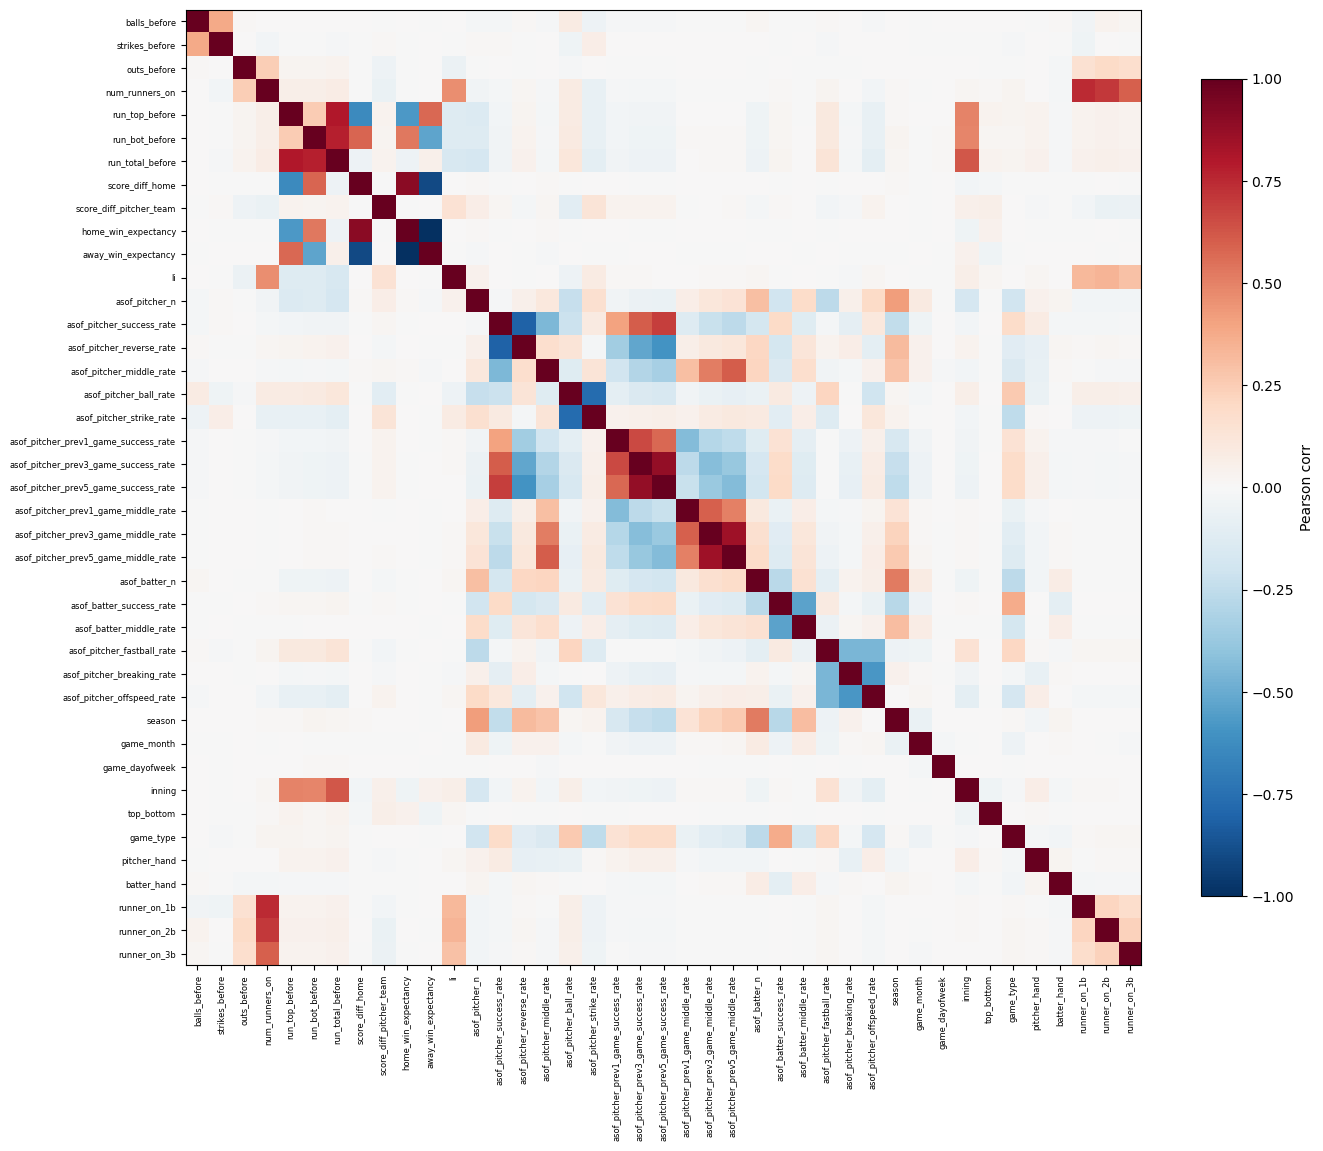

In [8]:
corr = correlation_matrix(train_df, TRAIN_TEST_NUMERIC + TRAIN_TEST_TIME_SERIES, TRAIN_TEST_BINARY)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson corr")
plt.tight_layout()
plt.show()

In [9]:
top_pairs = top_correlated_pairs(corr, top_n=20)
top_pairs

,col1,col2,corr
0,home_win_expectancy,away_win_expectancy,-1.000000
1,score_diff_home,away_win_expectancy,-0.904791
2,score_diff_home,home_win_expectancy,0.904789
3,asof_pitcher_prev3_game_success_rate,asof_pitcher_prev5_game_success_rate,0.882157
4,asof_pitcher_prev3_game_middle_rate,asof_pitcher_prev5_game_middle_rate,0.846332
5,asof_pitcher_success_rate,asof_pitcher_reverse_rate,-0.809942
6,run_top_before,run_total_before,0.804202
7,run_bot_before,run_total_before,0.779722
8,asof_pitcher_ball_rate,asof_pitcher_strike_rate,-0.773365
9,num_runners_on,runner_on_1b,0.745711


### 완전 중복 검증

상관계수가 정확히 ±1.0으로 나오는 쌍이 우연이 아니라 진짜 같은 값이거나 파생 관계인지 직접 검증한다 (이미 `asof_pitcher_pitchmix_n`은 스키마에서 뺐으니 그 외의 것들).

In [10]:
print("run_total_before == run_top_before + run_bot_before 인가:",
      ((train_df["run_top_before"] + train_df["run_bot_before"]) == train_df["run_total_before"]).all())

print("num_runners_on == runner_on_1b + runner_on_2b + runner_on_3b 인가:",
      ((train_df["runner_on_1b"] + train_df["runner_on_2b"] + train_df["runner_on_3b"]) == train_df["num_runners_on"]).all())

print("home_win_expectancy + away_win_expectancy 는 항상 100에 가까운가:")
print((train_df["home_win_expectancy"] + train_df["away_win_expectancy"]).describe()[["mean", "std", "min", "max"]])

run_total_before == run_top_before + run_bot_before 인가: True
num_runners_on == runner_on_1b + runner_on_2b + runner_on_3b 인가: True
home_win_expectancy + away_win_expectancy 는 항상 100에 가까운가:
mean    100.001408
std       0.019883
min      99.900000
max     100.100000
dtype: float64


**완전 중복/파생 (검증 완료)**: `run_total_before`=`run_top_before`+`run_bot_before`, `num_runners_on`=세 주자 플래그의 합, `home_win_expectancy`+`away_win_expectancy`≈100. 트리 모델은 다중공선성에 크게 영향받지 않아 그냥 둬도 되지만 "새 정보"라고 착각하면 안 됨.

**구조적으로 묶이는 그룹 (상관 0.5~0.9대)**: `asof_pitcher_success_rate`/`reverse_rate`/`ball_rate`/`strike_rate`(상호배타적 결과 분해로 추정), `asof_pitcher_prev1/3/5_game_*`끼리(겹치는 rolling window), `asof_pitcher_breaking_rate`/`offspeed_rate`(구종 비율 제로섬 구조로 추정).

## 5. 변수 중요도

`RandomForestClassifier`, `IMPORTANCE_SAMPLE_N=200,000`행 무작위 서브샘플(`random_state=42`로 재현 가능). 이진형/범주형은 `pd.factorize`로 정수코드화, 수치형/시계열형 결측치는 중앙값으로 임시 대체 (중요도 계산용, 실제 모델링에선 다르게 처리 — 부록 참고).

In [11]:
imp = feature_importance(
    train_df,
    TRAIN_TEST_BINARY + TRAIN_TEST_CATEGORICAL,
    TRAIN_TEST_NUMERIC + TRAIN_TEST_TIME_SERIES,
    TARGET,
)
imp

asof_pitcher_success_rate               0.124655
asof_pitcher_reverse_rate               0.097351
asof_pitcher_prev5_game_success_rate    0.082933
asof_pitcher_prev3_game_success_rate    0.070180
asof_batter_success_rate                0.067055
game_type                               0.060391
season                                  0.046512
asof_pitcher_prev1_game_success_rate    0.044010
asof_batter_middle_rate                 0.036929
asof_pitcher_ball_rate                  0.035103
asof_batter_n                           0.025426
asof_pitcher_middle_rate                0.023836
asof_pitcher_strike_rate                0.022663
asof_pitcher_n                          0.022412
asof_pitcher_offspeed_rate              0.020929
asof_pitcher_breaking_rate              0.019919
asof_pitcher_fastball_rate              0.019397
asof_pitcher_prev5_game_middle_rate     0.018917
asof_pitcher_prev3_game_middle_rate     0.016384
asof_pitcher_prev1_game_middle_rate     0.014443
li                  

In [12]:
OUT_DIR.mkdir(exist_ok=True)
missing.to_csv(OUT_DIR / "train_missing.csv")
corr.to_csv(OUT_DIR / "train_correlation.csv")
imp.to_csv(OUT_DIR / "train_feature_importance.csv")
print("saved to", OUT_DIR)

saved to /Users/choehabin/Library/CloudStorage/OneDrive-개인/lg aimers/모델링/eda/eda_outputs


## 부록 A. 도메인 규칙 검증

데이터 설명서에 적힌 두 가지가 실제로 지켜지는지 확인.

In [13]:
cold_start_check(train_df)

asof_pitcher_n == 0 인 행: 792건
asof_pitcher_success_rate               1.0
asof_pitcher_reverse_rate               1.0
asof_pitcher_middle_rate                1.0
asof_pitcher_ball_rate                  1.0
asof_pitcher_strike_rate                1.0
asof_pitcher_prev1_game_success_rate    1.0
asof_pitcher_prev3_game_success_rate    1.0
asof_pitcher_prev5_game_success_rate    1.0
asof_pitcher_prev1_game_middle_rate     1.0
asof_pitcher_prev3_game_middle_rate     1.0
asof_pitcher_prev5_game_middle_rate     1.0
asof_pitcher_fastball_rate              1.0
asof_pitcher_breaking_rate              1.0
asof_pitcher_offspeed_rate              1.0


In [14]:
base_state_consistency_check(train_df)

base_state 불일치 행: 0건 / 1475092건


## 부록 B. trackman_history.csv

train/test와 1:1로 안 붙는 별도 참고 데이터. 지금 베이스라인에서는 안 쓰기로 했지만(비용 대비 검증된 효과 없음, 대화 기록 참고) 구조만 같은 기준으로 훑어둔다.

In [15]:
tm_df = load("trackman_history.csv")
print(f"shape={tm_df.shape}")
tm_num = numeric_summary(tm_df, TRACKMAN_NUMERIC)
tm_num

shape=(1793078, 30)


,count,mean,std,min,50%,max,missing_ratio,skew
balls_before,1793078.0,0.9012,0.9726,0.0000,1.0000,4.0000,0.0000,0.7555
strikes_before,1793078.0,0.8603,0.8233,0.0000,1.0000,3.0000,0.0000,0.2637
outs_before,1793078.0,0.9798,0.8166,0.0000,1.0000,4.0000,0.0000,0.0379
pitch_of_pa,1793078.0,2.8922,1.7275,1.0000,3.0000,19.0000,0.0000,0.9169
rel_speed,1785461.0,135.9642,9.3717,71.6818,137.4120,160.6640,0.0042,-0.5620
spin_rate,1780613.0,2169.9693,338.0722,434.9000,2223.1700,3695.9200,0.0070,-1.1950
induced_vert_break,1783016.0,25.7838,24.3294,-81.8097,30.1050,153.3260,0.0056,-0.8415
horz_break,1782745.0,9.4542,25.8907,-78.9232,12.9918,103.6990,0.0058,-0.2796
extension,1785362.0,1.7591,0.1669,-0.3874,1.7600,3.8451,0.0043,-0.0429
rel_height,1785461.0,1.7032,0.2498,0.0971,1.7612,2.5121,0.0042,-2.5208


In [16]:
tm_ts = categorical_summary(tm_df, [c for c in TRACKMAN_TIME_SERIES if c != "game_date"])
print_categorical(tm_ts, with_rate=False)

- season (unique=6, missing=0.0)
    2024=334226, 2023=315100, 2022=307637, 2021=301032, 2020=279126, 2019=255957
- game_month (unique=9, missing=0.0)
    5=322449, 6=318442, 9=277933, 4=261023, 8=247860, 7=198818, 10=126176, 3=28815, 11=11562
- game_dayofweek (unique=7, missing=0.0)
    4=309594, 5=308098, 2=302977, 6=285375, 1=285120, 3=284215, 0=17699
- inning (unique=14, missing=0.0)
    1=209349, 7=204970, 6=203483, 8=203422, 5=201128, 3=199561, 4=199347, 2=198015, 9=153109, 10=12539, 11=5443, 12=2588
- pitch_no (unique=475, missing=0.0)
    113=5948, 58=5948, 60=5948, 84=5948, 15=5948, 83=5948, 82=5948, 32=5948, 70=5948, 97=5948, 42=5948, 57=5948


In [17]:
tm_cat = categorical_summary(tm_df, TRACKMAN_CATEGORICAL)
print_categorical(tm_cat, with_rate=False)

- pitcher_team (unique=26, missing=0.0)
    DOO_BEA=128074, NC_DIN=127091, LG_TWI=125354, HAN_EAG=124574, KIW_HER=124418, KT_WIZ=123456, LOT_GIA=123357, SAM_LIO=122442, SSG_LAN=84767, MIN_NCD=68421, MIN_DOO=65587, MIN_HAN=65442
- batter_team (unique=26, missing=0.0)
    KT_WIZ=131422, KIW_HER=128325, LG_TWI=127267, NC_DIN=126082, DOO_BEA=124893, HAN_EAG=121125, LOT_GIA=120402, SAM_LIO=120235, SSG_LAN=83232, KIA_TIG=66216, MIN_LGT=65993, MIN_HAN=65248
- tagged_pitch_type (unique=17, missing=0.0)
    Fastball=835886, Slider=359226, Curveball=174359, ChangeUp=170859, Splitter=101926, Sinker=101734, Cutter=37907, Undefined=7827, Other=2375, Sweeper=469, Changeup=225, Knuckleball=190
- auto_pitch_type (unique=11, missing=0.0)
    Fastball=417848, Four-Seam=336375, Slider=328182, Changeup=185311, Curveball=184666, Sinker=121539, ChangeUp=90324, Cutter=55354, Splitter=51174, Other=12263, Undefined=9970, nan=72
- pitch_type_group (unique=4, missing=0.0)
    fastball=931120, breaking=512851, of

## 부록 C. 다음 단계: 전처리 방향 (제안, 아직 미실행)

여기부터는 코드 실행 결과가 아니라 다음에 뭘 할지에 대한 제안. 실제 전처리 스크립트를 짜기 전에 방향을 맞추는 용도.

### 수치형 스케일링 — MinMax vs Standard

**결론: 최종 모델을 LightGBM 같은 트리 기반으로 간다면 둘 다 필요 없다.** 트리는 "이 값이 임계값보다 큰가"로 데이터를 나누기 때문에 어떤 단조변환(스케일링 포함)을 해도 분할 결과가 그대로다. 스케일링이 필요한 건 거리·계수 크기를 직접 쓰는 모델(선형/로지스틱회귀, SVM, KNN, 신경망)뿐이다.

혹시 나중에 앙상블에 선형/신경망 계열을 섞는다면 그때는 **StandardScaler를 기본으로 추천**한다. `li`, `score_diff_*`처럼 분포가 치우치고 극단값이 있는 변수가 섞여 있는데, MinMax는 극단값 하나가 나머지 전체 스케일을 눌러버리는 문제가 있고 StandardScaler가 상대적으로 덜 민감하다. `asof_*` rate 계열은 이미 0~1 근처라 스케일링 자체의 효과가 크지 않다.

### 범주형 인코딩

`base_state`/`pitcher_team_id`/`batter_team_id` 3개뿐이고 각각 최대 13개 값이라 원핫을 해도 컬럼이 29개 정도로 부담 없다. 다만 **LightGBM은 범주형을 네이티브로 지원**해서(컬럼을 `category` dtype으로만 바꿔주면 됨) 원핫 자체가 불필요하다. LightGBM으로 간다면 원핫 대신 네이티브 카테고리 지정을 추천.

### 시계열형 처리

- `season`: 순환 없이 계속 증가하니 그대로 수치로 사용 (검증됨 — 명목형으로 뒀을 때보다 중요도가 거의 두 배 높았음)
- `game_month`/`game_dayofweek`: 순환형이라 두 가지 선택지가 있다. (1) 범주형으로 취급(원핫 또는 LightGBM 네이티브 카테고리) — 지금 스키마가 이 방식. (2) sin/cos로 순환 인코딩. 트리 모델은 (1)로도 임의의 월별 효과를 학습할 수 있어서 sin/cos의 이점이 크지 않다. **트리 모델이면 (1) 그대로가 더 단순하고 충분하다는 게 제 결론.**
- `inning`: 그대로 수치로 두되, 연장전(10회 이상)이 마무리 투수 소진 등으로 완전히 다른 상황일 수 있다는 아이디어가 있었다. `is_extra_inning = (inning >= 10)` 이진 플래그를 추가하는 걸 모델링 단계 피처 엔지니어링 후보로 제안.

### 구간 기반(threshold) 파생 피처

모든 수치형이 매끄러운 선형 관계는 아니다. `asof_pitcher_success_rate`처럼 구간을 나눠도 쭉 단조증가하는 변수는 raw 값 그대로가 최선이지만(3절에서 검증), 특정 값을 기준으로 상황 자체가 바뀌는(regime change) 변수는 raw 값에 구간 플래그를 추가하는 게 나을 수 있다. 트리 모델이 이론상 스스로 그 임계값을 찾을 수 있어도, 도메인 지식으로 미리 지정해주면 더 적은 데이터로 안정적으로 학습한다. `season≥2023 × game_type=F` regime 플래그가 이후 실험에서 실제로 유효했다 — 이 방식의 성공 사례.

| 피처 | 임계값 | 근거 |
| --- | --- | --- |
| `is_extra_inning` | `inning >= 10` | 연장전은 마무리 투수 소진, 평소 안 던지는 투수 등판 등으로 상황 자체가 다름 |
| `season_regime` | `season >= 2023` | 2023년부터 성공률 추세가 꺾이는 구간 |
| `is_full_count` | `balls_before==3 & strikes_before==2` | 풀카운트는 투수가 반드시 승부를 봐야 하는 특수 상황 |
| `pitcher_experience_tier` | `asof_pitcher_n` 구간(<50 / 50~500 / 500+) | cold-start 구간(n≤50)은 EB smoothing으로 따로 처리하면 효과 있음 |

원본 수치형은 그대로 두고 이 플래그들을 **추가**하는 방향 — raw 값의 세밀한 정보를 잃지 않으면서 regime 경계를 명시적으로 알려주는 것.

### 결측치 처리 (변수별로 상의가 필요한 부분)

**결론부터: LightGBM을 쓸 거면 아무것도 안 채우고 NaN 그대로 넘기는 게 제일 낫다.** LightGBM은 학습 중에 결측치를 어느 쪽 분기로 보낼지 데이터로부터 직접 학습한다 — 이게 사람이 정한 고정 규칙(중앙값, KNN 등)보다 이론적으로 우월하다 (손실을 최소화하는 방향으로 최적화됨).

| 결측 그룹 | 원인 | 제안 |
| --- | --- | --- |
| `asof_pitcher_*`, `asof_batter_*` (0.05~0.06%) | `n==0`, 완전 첫 투구 | NaN 그대로 LightGBM에 전달. 원하면 `is_pitcher_cold_start`(=n==0) 플래그 추가로 명시적 신호 제공 |
| `asof_pitcher_prev1/3/5_game_*` (1.98%) | 직전 N경기 이력 없음 | 위와 동일 |

다만 이걸 로지스틱 회귀 같은 결측치를 못 받는 모델과 같이 비교하고 싶다면, 그때는 중앙값/KNN 대신 **Empirical Bayes smoothing**(전체 평균 쪽으로 표본수에 비례해 당기는 방식, `smoothed = (n·rate + k·prior) / (n+k)`)을 추천한다 — 실제로 효과가 검증된 방법이고, "표본이 적을수록 전체 평균을 신뢰"한다는 통계적으로 타당한 논리다. KNN은 이 결측이 무작위가 아니라 "이력 자체가 없음"이라는 구조적 이유라서 남의 값을 빌려오는 게 논리적으로 안 맞고, 행 삭제는 test(2025, 처음 보는 투수 많음)에서 자주 나올 유형을 학습에서 빼는 셈이라 제일 위험하다.

**다음 확인해야 할 것**: 최종 모델을 LightGBM 하나로 갈지 여러 모델 블렌드로 갈지부터 정하면 결측치 전략이 자동으로 갈린다. 이 부분 결정되면 전처리 스크립트(`preprocess.py`)를 만들고 결과를 `data/processed/`에 저장하는 걸로 진행하면 될 것 같다.